<a href="https://colab.research.google.com/github/karoka011/Student-Analysis/blob/main/Students_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student academic performance Analysis

#1. Data Understanding

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import kagglehub
import seaborn as sns

In [ ]:
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

Using Colab cache for faster access to the 'xapi-edu-data' dataset.


In [ ]:
edu_df = pd.read_csv('/kaggle/input/xapi-edu-data/xAPI-Edu-Data.csv')
edu_df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [ ]:
edu_df['Semester'].unique()

array(['F', 'S'], dtype=object)

In [ ]:
edu_df['Class'].value_counts(normalize=True) # normalize = true gives me a porcentual distribution

,proportion
Class,
M,0.439583
H,0.295833
L,0.264583


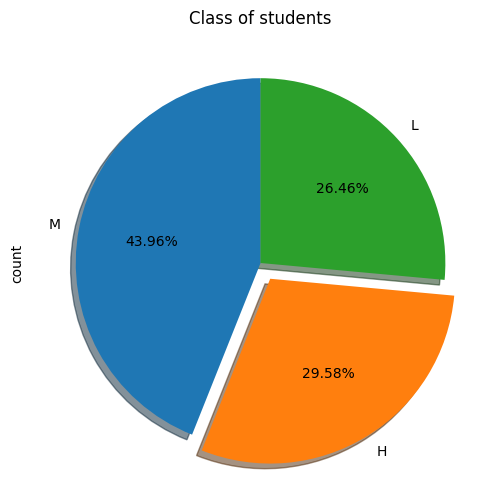

In [ ]:
edu_df['Class'].value_counts().plot(kind='pie',autopct='%.2f%%',startangle=90,shadow=True,explode=[0,0.1,0],figsize=(6,6))
plt.title('Class of students')
plt.show()

In [ ]:
edu_df.groupby('Class')[['raisedhands','VisITedResources']].mean()

,raisedhands,VisITedResources
Class,,
H,70.288732,78.746479
L,16.889764,18.322835
M,48.938389,60.635071


In [ ]:
edu_df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
#edu_df['StudentAbsenceDays'].unique()
edu_df['Morethan7AbsentDays'] = edu_df['StudentAbsenceDays'].apply(lambda x: 1 if x=='Above-7' else 0)
edu_df = edu_df.drop('StudentAbsenceDays',axis=1)
edu_df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,Class,Morethan7AbsentDays
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,M,0
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,M,0
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,L,1
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,L,1
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,M,1


# Bevahior

In [ ]:
edu_df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Morethan7AbsentDays
count,480.000000,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333,0.397917
std,30.779223,33.080007,26.611244,27.637735,0.489979
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,15.750000,20.000000,14.000000,20.000000,0.000000
50%,50.000000,65.000000,33.000000,39.000000,0.000000
75%,75.000000,84.000000,58.000000,70.000000,1.000000
max,100.000000,99.000000,98.000000,99.000000,1.000000


In [ ]:
behavior_cols = ['VisITedResources','AnnouncementsView','Discussion','raisedhands']
edu_df.groupby('Class')[behavior_cols].mean()

,VisITedResources,AnnouncementsView,Discussion,raisedhands
Class,,,,
H,78.746479,53.380282,53.661972,70.288732
L,18.322835,15.574803,30.834646,16.889764
M,60.635071,40.962085,43.791469,48.938389


Students with more engagement and participation get the higher grades

In [ ]:
edu_df.groupby('Class')['Morethan7AbsentDays'].mean()

,Morethan7AbsentDays
Class,
H,0.028169
L,0.913386
M,0.336493


#Rendimiento Escolar debido a las Influencias Familiares

In [ ]:
edu_df.Relation.unique()

array(['Father', 'Mum'], dtype=object)

In [ ]:
edu_df.groupby('Class')['Relation'].value_counts(normalize=True)

Class  Relation
H      Mum         0.704225
       Father      0.295775
L      Father      0.818898
       Mum         0.181102
M      Father      0.649289
       Mum         0.350711
Name: proportion, dtype: float64

In [ ]:
edu_df.groupby('Class')['ParentschoolSatisfaction'].value_counts(normalize=True)

Class  ParentschoolSatisfaction
H      Good                        0.830986
       Bad                         0.169014
L      Bad                         0.661417
       Good                        0.338583
M      Good                        0.620853
       Bad                         0.379147
Name: proportion, dtype: float64

In [ ]:
edu_df['EngagementScore'] = edu_df['Discussion'] + edu_df['AnnouncementsView'] + edu_df['VisITedResources'] + edu_df['raisedhands']
edu_df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,Class,Morethan7AbsentDays,EngagementScore,HighPerformance
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,M,0,53,1
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,M,0,68,1
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,L,1,47,0
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,L,1,95,0
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,M,1,152,1


In [ ]:
edu_df.groupby('Class')['EngagementScore'].mean()

,EngagementScore
Class,
H,256.077465
L,81.622047
M,194.327014


Text(0, 0.5, 'Engagement Score')

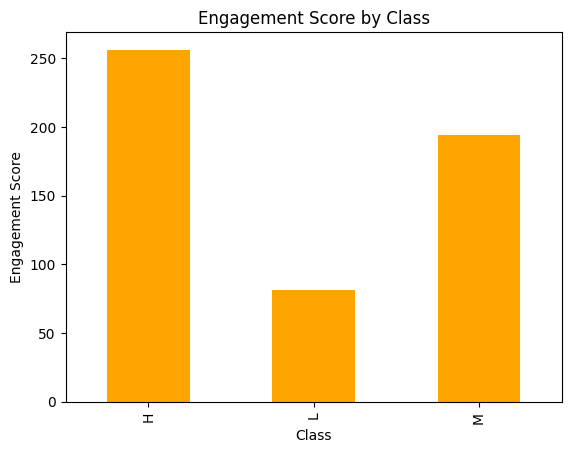

In [ ]:
edu_df.groupby('Class')['EngagementScore'].mean().plot(kind='bar',color='orange')
plt.title('Engagement Score by Class')
plt.xlabel('Class')
plt.ylabel('Engagement Score')


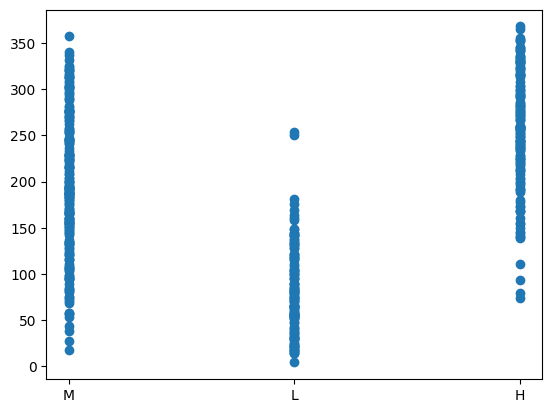

In [ ]:
plt.scatter(edu_df['Class'],edu_df['EngagementScore'])
plt.show()

# Relation between a student class and their engagement

In [ ]:
edu_df['HighPerformance'] = edu_df['Class'].apply(lambda x: 1 if x=='M' else 0)
#edu_df = edu_df.drop('HighPermormance',axis=1)
edu_df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,Class,Morethan7AbsentDays,EngagementScore,HighPerformance
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,M,0,53,1
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,M,0,68,1
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,L,1,47,0
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,L,1,95,0
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,M,1,152,1


In [ ]:
edu_corr = edu_df.corr(method='pearson',numeric_only=True)
edu_corr

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Morethan7AbsentDays,EngagementScore,HighPerformance
raisedhands,1.000000,0.691572,0.643918,0.339386,-0.463882,0.861537,0.062315
VisITedResources,0.691572,1.000000,0.594500,0.243292,-0.499030,0.826491,0.156442
AnnouncementsView,0.643918,0.594500,1.000000,0.417290,-0.312134,0.834219,0.101392
Discussion,0.339386,0.243292,0.417290,1.000000,-0.218778,0.615072,0.016300
Morethan7AbsentDays,-0.463882,-0.499030,-0.312134,-0.218778,1.000000,-0.485066,-0.111142
EngagementScore,0.861537,0.826491,0.834219,0.615072,-0.485066,1.000000,0.110060
HighPerformance,0.062315,0.156442,0.101392,0.016300,-0.111142,0.110060,1.000000


In [ ]:
edu_corr.index

Index(['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'Morethan7AbsentDays', 'EngagementScore', 'HighPerformance'],
      dtype='object')

Grafico correlacion lineal

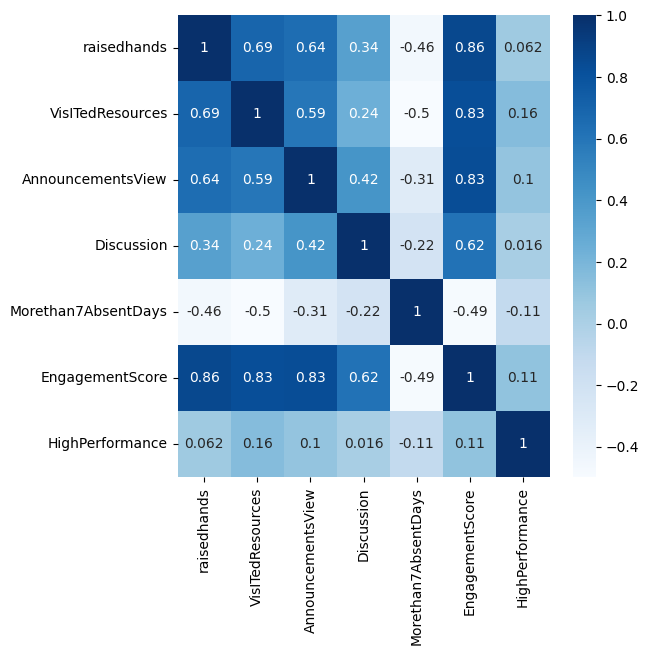

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(edu_corr,annot=True,cmap='Blues')
sns.set(font_scale=1.25)
plt.show()

In [ ]:
edu_corr['HighPerformance'].sort_values(ascending=False)[1:] #To show the variable that are associated with hight performance
#i dont wnat to show the high Performance variable compared to itself

,HighPerformance
VisITedResources,0.156442
EngagementScore,0.110060
AnnouncementsView,0.101392
raisedhands,0.062315
Discussion,0.016300
Morethan7AbsentDays,-0.111142


In [ ]:
mostRelationVaraibles = edu_corr['HighPerformance'].sort_values(ascending=False)[1:5].index
mostRelationVaraibles

Index(['VisITedResources', 'EngagementScore', 'AnnouncementsView',
       'raisedhands'],
      dtype='object')

In [ ]:
edu_df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,Class,Morethan7AbsentDays,EngagementScore,HighPerformance
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,M,0,53,1
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,M,0,68,1
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,L,1,47,0
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,L,1,95,0
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,M,1,152,1


In [ ]:
print(behavior_cols)

['VisITedResources', 'AnnouncementsView', 'Discussion', 'raisedhands']


In [ ]:
edu_df.groupby('HighPerformance')[behavior_cols].mean().sort_values(by='VisITedResources',ascending=False)

,VisITedResources,AnnouncementsView,Discussion,raisedhands
HighPerformance,,,,
1,60.635071,40.962085,43.791469,48.938389
0,50.219331,35.531599,42.884758,45.078067


## Evaluar la presencia de outliers
y la distribuvion de cada una de las variables

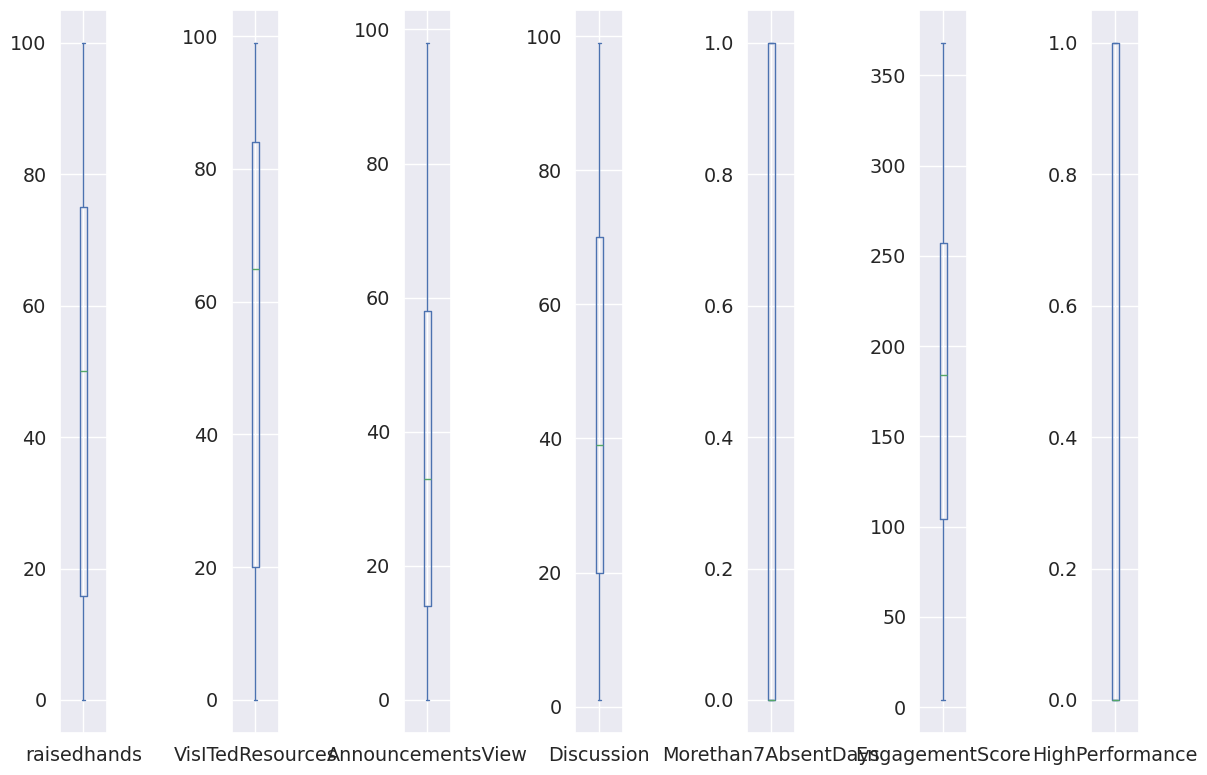

In [ ]:
edu_df.plot(kind='box',figsize=(12,8),subplots = True, sharex=True, sharey=False)
plt.tight_layout()
plt.show()

## Create the logistic Regression model

this model will predict the probability of a student being a high performance student based on certain variables

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Set de prueba y entrenamiento

In [ ]:
y = edu_df.HighPerformance
X = edu_df[mostRelationVaraibles]
X.head()

,VisITedResources,EngagementScore,AnnouncementsView,raisedhands
0,16,53,2,15
1,20,68,3,20
2,7,47,0,10
3,25,95,5,30
4,50,152,12,40


In [ ]:
X_en,X_pru,Y_en,Y_pru = train_test_split(X,y,test_size=0.2,random_state=42)

Hacer el esclado con StandarScaler

In [ ]:
escalador_std = StandardScaler()
X_en = escalador_std.fit_transform(X_en)
X_pru = escalador_std.transform(X_pru)

In [ ]:
model = LogisticRegression()
model.fit(X_en,Y_en)

LogisticRegression()

In [ ]:
model.classes_

array([0, 1])

In [ ]:
model.intercept_

array([-0.31082031])

## Validacion

In [ ]:
model.score(X_pru,Y_pru)

0.5

In [ ]:
predict = model.predict(X_pru)
predict

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1])

In [ ]:
print("Predicciones:")
print(predict[:5])
print("Valores Reales")
print(Y_pru[:5])

Predicciones:
[0 0 0 0 1]
Valores Reales
73     1
414    0
394    0
277    0
399    0
Name: HighPerformance, dtype: int64


In [ ]:
m_conf = confusion_matrix(Y_pru,predict)
pd.DataFrame(m_conf,columns=[['Real']*2,model.classes_],index=[['Prediccion']*2,model.classes_])

Real   
                0  1
Prediccion 0   44  4
           1   44  4

In [ ]:
print(classification_report(Y_pru,predict))

              precision    recall  f1-score   support

           0       0.50      0.92      0.65        48
           1       0.50      0.08      0.14        48

    accuracy                           0.50        96
   macro avg       0.50      0.50      0.39        96
weighted avg       0.50      0.50      0.39        96



## 2 Modelo sin 'Engagement Score'

In [ ]:
y1 = edu_df.HighPerformance
X1 = edu_df[behavior_cols]
X1.head()

,VisITedResources,AnnouncementsView,Discussion,raisedhands
0,16,2,20,15
1,20,3,25,20
2,7,0,30,10
3,25,5,35,30
4,50,12,50,40


In [ ]:
X1_en,X1_pru,Y1_en,Y1_pru = train_test_split(X1,y1,train_size=0.2,random_state=42)

In [ ]:
X1_en = escalador_std.fit_transform(X1_en)
X1_pru = escalador_std.transform(X1_pru)

In [ ]:
model2 = LogisticRegression()
model2.fit(X1_en,Y1_en)

LogisticRegression()

In [ ]:
model2.score(X1_pru,Y1_pru)

0.5234375

In [ ]:
Y1_pru

,HighPerformance
73,1
414,0
394,0
277,0
399,0
...,...
216,1
279,1
417,0
455,1


In [ ]:
y_pre = model2.predict(X1_pru)
y_pre

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,

In [ ]:
m2_conf = confusion_matrix(Y1_pru,y_pre)
pd.DataFrame(m2_conf,columns=[['Real']*2,model2.classes_],index=[['Prediccion']*2,model2.classes_])

Real    
                0   1
Prediccion 0  130  88
           1   95  71

In [ ]:
print(classification_report(Y1_pru,y_pre))

              precision    recall  f1-score   support

           0       0.58      0.60      0.59       218
           1       0.45      0.43      0.44       166

    accuracy                           0.52       384
   macro avg       0.51      0.51      0.51       384
weighted avg       0.52      0.52      0.52       384



Aunque se observó una relación positiva entre el engagement académico y el rendimiento escolar, los modelos lineales presentan un desempeño limitado. Esto sugiere que el rendimiento académico no depende únicamente de variables de comportamiento registradas en la plataforma, sino también de factores externos no presentes en el dataset.